In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import sys

sys.path.append('../')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Bidirectional,
                                     LSTM, Dense, Dropout, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from scipy.sparse import issparse

print("TensorFlow:", tf.__version__)
print("All imports successful!")

In [ ]:
df = pd.read_csv('../data/cleaned_data.csv')
df = df.dropna(subset=['cleaned_text'])

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['label'],
    test_size=0.3,
    random_state=42
)

y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 50424
Test size : 21611


In [ ]:
# TF-IDF vectorizer for the statistical branch
MAX_TFIDF = 10000  # keep top 10k features for this branch

tfidf_hybrid = TfidfVectorizer(
    max_features=MAX_TFIDF,
    ngram_range=(1, 2),
    sublinear_tf=True
)

# Fit on train only
X_train_tfidf = tfidf_hybrid.fit_transform(X_train)
X_test_tfidf  = tfidf_hybrid.transform(X_test)

# Convert sparse matrix to dense for Keras
X_train_tfidf_dense = X_train_tfidf.toarray().astype('float32')
X_test_tfidf_dense  = X_test_tfidf.toarray().astype('float32')

print("TF-IDF train shape:", X_train_tfidf_dense.shape)
print("TF-IDF test shape :", X_test_tfidf_dense.shape)

# Save hybrid tfidf vectorizer
with open('../models/tfidf_hybrid.pkl', 'wb') as f:
    pickle.dump(tfidf_hybrid, f)
print("Hybrid TF-IDF vectorizer saved!")


TF-IDF train shape: (50424, 10000)
TF-IDF test shape : (21611, 10000)
Hybrid TF-IDF vectorizer saved!


In [ ]:
MAX_WORDS = 50000
MAX_LEN   = 300
EMBED_DIM = 128

# Tokenizer for BiLSTM branch
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print("Sequence train shape:", X_train_pad.shape)
print("Sequence test shape :", X_test_pad.shape)

# Save tokenizer
with open('../models/hybrid_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Hybrid tokenizer saved!")

Sequence train shape: (50424, 300)
Sequence test shape : (21611, 300)
Hybrid tokenizer saved!


In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

def build_hybrid_model_v3(max_words, max_len, embed_dim, tfidf_dim):
    
    # --- Branch 1: BiLSTM ---
    seq_input = Input(shape=(max_len,), name='sequence_input')
    x1 = Embedding(input_dim=max_words,
                   output_dim=embed_dim,
                   input_length=max_len)(seq_input)
    
    # L2 regularization added to LSTM — penalizes large weights
    x1 = Bidirectional(LSTM(
        64,
        return_sequences=False,
        kernel_regularizer=l2(0.01),    # NEW
        recurrent_regularizer=l2(0.01)  # NEW
    ))(x1)
    x1 = Dropout(0.5)(x1)
    x1 = Dense(64, activation='relu',
                kernel_regularizer=l2(0.01))(x1)  # NEW

    # --- Branch 2: TF-IDF ---
    tfidf_input = Input(shape=(tfidf_dim,), name='tfidf_input')
    x2 = Dense(128, activation='relu',
                kernel_regularizer=l2(0.01))(tfidf_input)  # NEW
    x2 = Dropout(0.4)(x2)
    x2 = Dense(64, activation='relu',
                kernel_regularizer=l2(0.01))(x2)  # NEW

    # --- Merge ---
    merged = Concatenate()([x1, x2])
    x = Dense(64, activation='relu',
               kernel_regularizer=l2(0.01))(merged)  # NEW
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=[seq_input, tfidf_input], outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=0.0003),  # even slower learning
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

hybrid_model_v3 = build_hybrid_model_v3(
    MAX_WORDS, MAX_LEN, EMBED_DIM, MAX_TFIDF
)
hybrid_model_v3.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop_v3 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_v3 = ModelCheckpoint(
    '../models/hybrid_best_v3.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# NEW — automatically reduces learning rate when val_loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # halve the learning rate
    patience=2,        # after 2 epochs of no improvement
    min_lr=0.00001,
    verbose=1
)

print("Training Hybrid Model v3...")

history_v3 = hybrid_model_v3.fit(
    [X_train_pad, X_train_tfidf_dense],
    y_train_arr,
    epochs=15,
    batch_size=128,      # larger batch = more stable gradients
    validation_split=0.1,
    callbacks=[early_stop_v3, checkpoint_v3, reduce_lr],
    verbose=1
)

In [ ]:
y_pred_prob = hybrid_model_v3.predict([X_test_pad, X_test_tfidf_dense])
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

acc  = accuracy_score(y_test_arr, y_pred)
prec = precision_score(y_test_arr, y_pred)
rec  = recall_score(y_test_arr, y_pred)
f1   = f1_score(y_test_arr, y_pred)

print("="*45)
print("  Hybrid Model v3 Results")
print("="*45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")

In [ ]:

"""

def build_hybrid_model(max_words, max_len, embed_dim, tfidf_dim):
    
    # --- Branch 1: BiLSTM (sequence input) ---
    seq_input = Input(shape=(max_len,), name='sequence_input')
    x1 = Embedding(input_dim=max_words,
                   output_dim=embed_dim,
                   input_length=max_len)(seq_input)
    x1 = Bidirectional(LSTM(128, return_sequences=False))(x1)
    x1 = Dropout(0.4)(x1)
    x1 = Dense(128, activation='relu')(x1)

    # --- Branch 2: TF-IDF (statistical input) ---
    tfidf_input = Input(shape=(tfidf_dim,), name='tfidf_input')
    x2 = Dense(256, activation='relu')(tfidf_input)
    x2 = Dropout(0.3)(x2)
    x2 = Dense(128, activation='relu')(x2)

    # --- Merge both branches ---
    merged = Concatenate()([x1, x2])
    x = Dense(128, activation='relu')(merged)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    output = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(
        inputs=[seq_input, tfidf_input],
        outputs=output
    )

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Build model
hybrid_model = build_hybrid_model(
    max_words=MAX_WORDS,
    max_len=MAX_LEN,
    embed_dim=EMBED_DIM,
    tfidf_dim=MAX_TFIDF
)

hybrid_model.summary()

"""

c:\sem4_project\FakeNewsDetection\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  6,400,000 │ sequence_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tfidf_input         │ (None, 10000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256)       │    263,168 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  2,560,256 │ tfidf_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,330,433 (35.59 MB)

 Trainable params: 9,330,433 (35.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
"""
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '../models/hybrid_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Training Hybrid Model...")
print("This will take 15-25 minutes on CPU\n")

history = hybrid_model.fit(
    [X_train_pad, X_train_tfidf_dense],  # two inputs
    y_train_arr,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nTraining complete!")


"""

Training Hybrid Model...
This will take 15-25 minutes on CPU

Epoch 1/100
670/670 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9026 - loss: 0.2012
Epoch 1: val_accuracy improved from None to 0.97541, saving model to ../models/hybrid_best.keras

Epoch 1: finished saving model to ../models/hybrid_best.keras
670/670 ━━━━━━━━━━━━━━━━━━━━ 403s 593ms/step - accuracy: 0.9554 - loss: 0.1094 - val_accuracy: 0.9754 - val_loss: 0.0730
Epoch 2/100
670/670 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.9946 - loss: 0.0159
Epoch 2: val_accuracy improved from 0.97541 to 0.97911, saving model to ../models/hybrid_best.keras

Epoch 2: finished saving model to ../models/hybrid_best.keras
670/670 ━━━━━━━━━━━━━━━━━━━━ 461s 688ms/step - accuracy: 0.9947 - loss: 0.0158 - val_accuracy: 0.9791 - val_loss: 0.0749
Epoch 3/100
670/670 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.9981 - loss: 0.0065
Epoch 3: val_accuracy did not improve from 0.97911
670/670 ━━━━━━━━━━━━━━━━━━━━ 457s 682ms/step - accuracy

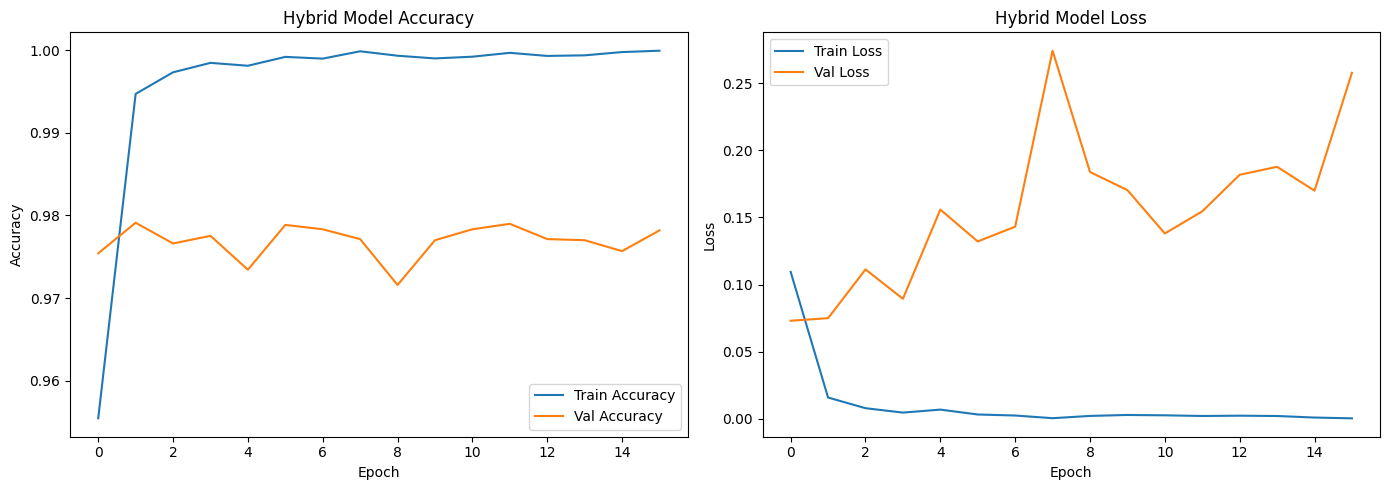

Training curves saved!


In [ ]:
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Hybrid Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Hybrid Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/hybrid_training_curves.png')
plt.show()
print("Training curves saved!")
"""

676/676 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step
  Hybrid Model (TF-IDF + BiLSTM) Results
  Accuracy  : 0.9745
  Precision : 0.9581
  Recall    : 0.9943
  F1-Score  : 0.9758

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.95      0.97     10445
        Fake       0.96      0.99      0.98     11166

    accuracy                           0.97     21611
   macro avg       0.98      0.97      0.97     21611
weighted avg       0.98      0.97      0.97     21611



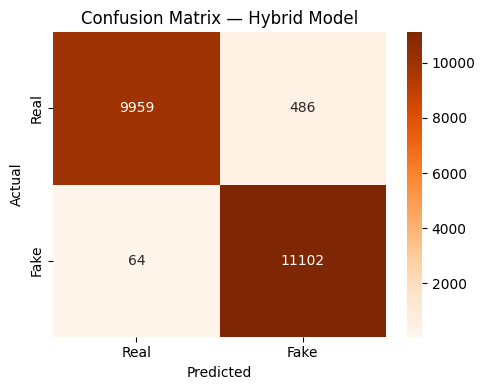


           FINAL MODEL COMPARISON TABLE
                 Model  Accuracy  Precision  Recall     F1
           Naive Bayes    0.8815     0.8751  0.9019 0.8883
   Logistic Regression    0.9643     0.9639  0.9678 0.9659
                BiLSTM    0.9681     0.9599  0.9799 0.9698
                   SVM    0.9766     0.9743  0.9811 0.9777
Hybrid (TF-IDF+BiLSTM)    0.9745     0.9581  0.9943 0.9758

Final comparison saved → models/final_comparison.csv


In [ ]:
# Predict
y_pred_prob = hybrid_model.predict([X_test_pad, X_test_tfidf_dense])
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

acc  = accuracy_score(y_test_arr, y_pred)
prec = precision_score(y_test_arr, y_pred)
rec  = recall_score(y_test_arr, y_pred)
f1   = f1_score(y_test_arr, y_pred)

print("="*45)
print("  Hybrid Model (TF-IDF + BiLSTM) Results")
print("="*45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_arr, y_pred,
                            target_names=['Real', 'Fake']))

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix — Hybrid Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../models/Hybrid_confusion.png')
plt.show()

# Final comparison table
print("\n" + "="*60)
print("           FINAL MODEL COMPARISON TABLE")
print("="*60)
comparison = pd.DataFrame([
    {'Model': 'Naive Bayes',         'Accuracy': 0.8815,
     'Precision': 0.8751, 'Recall': 0.9019, 'F1': 0.8883},
    {'Model': 'Logistic Regression', 'Accuracy': 0.9643,
     'Precision': 0.9639, 'Recall': 0.9678, 'F1': 0.9659},
    {'Model': 'BiLSTM',              'Accuracy': 0.9681,
     'Precision': 0.9599, 'Recall': 0.9799, 'F1': 0.9698},
    {'Model': 'SVM',                 'Accuracy': 0.9766,
     'Precision': 0.9743, 'Recall': 0.9811, 'F1': 0.9777},
    {'Model': 'Hybrid (TF-IDF+BiLSTM)', 'Accuracy': round(acc, 4),
     'Precision': round(prec, 4), 'Recall': round(rec, 4),
     'F1': round(f1, 4)},
])
print(comparison.to_string(index=False))
comparison.to_csv('../models/final_comparison.csv', index=False)
print("\nFinal comparison saved → models/final_comparison.csv")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Model
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=5000, output_dim=128))

# BiLSTM layer
model.add(Bidirectional(LSTM(64)))

# 🔥 Dropout added (reduces overfitting)
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 🔥 Early stopping added
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=6,  # 🔥 reduced epochs
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

NameError: name 'X_val' is not defined